# Polarization ratio and F/B 
in this notebook Figures 6-9 of paper Haberstock et al. 2026 (submitted to AMT) are being generated

It uses the following datasets: 
- GFAS PbP data on August 11, 12, and 16 2024 during the measurement campaign at SBO accessible @ bolin centre database (will add DOI)
- scale factors in PbP_processing/detector_scaling_factors
- cloudevent table cloudevents.csv of the campaign at SBO

Sub-routines needed:
- PbP_processing/GFAS101_processing
- calibrations/MieCalculations
- GFAS_reading/GFAS101_read_in


author: Lea Haberstock, Stockholm University, Department of Environmental Science, Atmospheric Unit \
developed toether with: Darrel Baumgardner and Paul Zieger

contact: lea.haberstock@aces.su.se \
used in publication: Haberstock et al. 2026 (submitted to AMT) 

Last modified June 30 2026

In [ ]:
import sys  
import numpy as np
import pandas as pd
import glob2
import glob, os
import os
from io import BytesIO
import datetime as dt
import calendar
from pandas.errors import EmptyDataError
from scipy.ndimage import shift
import scipy
import metpy
from metpy.calc import wind_components,wind_speed,wind_direction
from metpy.units import units
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as colors
import shapely 
import matplotlib.ticker as ticker
import matplotlib 
import PyMieScatt  as pms
from scipy.stats import linregress
import dask
import dask.dataframe as dd
from pathlib import Path

project_dir = Path.cwd().parent
sys.path.append(str(project_dir))
from PbP_processing.GFAS101_processing import *
from calibrations.MieCalculations import *
from GFAS_reading.GFAS101_read_in import *


#### read in 

In [ ]:
# change to your work directory
os.chdir('')
path = 'PbP_processing/detector_scaling_factors'
scales = (pd.read_csv(path, index_col = 0)).squeeze()

In [17]:
cloudevents = pd.read_csv('plots/cloudevents.csv', index_col=0 )

In [18]:
# size bins 
bi = np.array([0,3,5,9,14,21,50])

In [ ]:
path = '/static/StationData/Campaigns/CIS_Sonnblick2024/GFAS'
starttime = '20240811'
endtime = '20240812'
timefmt = '%Y%m%d'

cloud1 = readPbP101(path, starttime, starttime, timefmt, filetype='GFAS_PbP_Data', compute=False)
cloud1 = cloud1[cloud1['datetime'] >= cloudevents.loc[9, 'Start']]
cloud2 = readPbP101(path, endtime, endtime, timefmt, filetype='GFAS_PbP_Data', compute=False)
cloud2 = cloud2[cloud2['datetime'] <= cloudevents.loc[9, 'End']]

cloud = dd.concat([cloud1, cloud2], ignore_index=True)
cloud = cloud.map_partitions(attenuation)
cloud = cloud.map_partitions(qual_filter)

cloud['scaled Sizer Peak'] = cloud['Sizer Peak'] * scales['forward']
cloud['scaled Sizer S'] = cloud['S Peak'] * scales['S']
cloud['scaled Sizer P'] = cloud['P Peak'] * scales['P']
cloud['scaled r_pol'] = (cloud['scaled Sizer S'] - cloud['scaled Sizer P']) / (cloud['scaled Sizer S'] + cloud['scaled Sizer P'])
cloud['scaled F/B'] = cloud['scaled Sizer Peak']/(cloud['scaled Sizer S'] + cloud['scaled Sizer P'])
bins = np.logspace(np.log10(1e-7), np.log10(5.357364e-06), 31)
cloud['binned Sizer Peak'] = cloud['scaled Sizer Peak'].map_partitions(pd.cut, bins=bins, labels=bins[1:], include_lowest=True, meta=pd.Series(dtype="category"))

meta = sizing_model(cloud._meta.copy())
cloud = cloud.map_partitions(sizing_model, meta=meta)
cloud['binned Diameter'] = cloud['Diameter'].map_partitions(pd.cut, bins = bi, labels  = bi[1:], include_lowest = True)
cloud = cloud.compute()


In [10]:
path = '/static/StationData/Campaigns/CIS_Sonnblick2024/GFAS'
starttime = '20240816'
endtime = '20240816'
timefmt = '%Y%m%d'

dust = readPbP101(path, starttime, endtime, timefmt, filetype='GFAS_PbP_Data', compute=False)

Scheduled 444 CSV and 0 ZIP files.


In [11]:
dust = dust[(dust['datetime'] >= pd.to_datetime('2024-08-16 03:00'))& (dust['datetime'] <= pd.to_datetime('2024-08-16 12:00'))]

dust = dust.map_partitions(attenuation)
dust = dust.map_partitions(qual_filter)
dust['scaled Sizer Peak'] = dust['Sizer Peak'] * scales['forward']
dust['scaled Sizer S'] = dust['S Peak'] * scales['S']
dust['scaled Sizer P'] = dust['P Peak'] * scales['P']
dust['scaled r_pol'] = (dust['scaled Sizer S'] - dust['scaled Sizer P']) / (dust['scaled Sizer S'] + dust['scaled Sizer P'])
dust['scaled F/B'] = dust['scaled Sizer Peak']/(dust['scaled Sizer S'] + dust['scaled Sizer P'])

bins = np.logspace(np.log10(1e-7), np.log10(5.357364e-06), 31)
dust['binned Sizer Peak'] = dust['scaled Sizer Peak'].map_partitions(pd.cut, bins=bins, labels=bins[1:], include_lowest=True, meta=pd.Series(dtype="category"))

meta = sizing_model(dust._meta.copy())
dust = dust.map_partitions(sizing_model, meta=meta)
dust['binned Diameter'] = dust['Diameter'].map_partitions(pd.cut, bins = bi, labels  = bi[1:], include_lowest = True)
dust = dust.compute()

In [19]:
# add lab experiments
dustIceland  = pd.read_csv('/share/Lea/data/LabExperiments2024/dustIceland.csv', index_col=0)
DustSvalbard  = pd.read_csv('/share/Lea/data/LabExperiments2024/DustSvalbard.csv', index_col=0)
volcano  = pd.read_csv('/share/Lea/data/LabExperiments2024/volcano.csv', index_col=0)
cellulose  = pd.read_csv('/share/Lea/data/LabExperiments2024/cellulose.csv', index_col=0)
glassbeads15  = pd.read_csv('/share/Lea/data/LabExperiments2024/glassbeads15.csv', index_col=0)
maxi  = pd.read_csv('/share/Lea/data/LabExperiments2024/maxi.csv', index_col=0)
mid  = pd.read_csv('/share/Lea/data/LabExperiments2024/mid.csv', index_col=0)
mini  = pd.read_csv('/share/Lea/data/LabExperiments2024/mini.csv', index_col=0)
wick = pd.concat([maxi,mid,mini])

df = [volcano, cellulose, glassbeads15, wick] # DustSvalbard, dustIceland,
for D in [volcano, cellulose, glassbeads15, wick]:
    qual_filter(D)
    attenuation(D)
    sizing_model(D)
    D['scaled Sizer Peak'] = D['Sizer Peak'] * scales['forward']
    D['scaled Sizer S'] = D['S Peak'] * scales['S']
    D['scaled Sizer P'] = D['P Peak'] * scales['P']
    D['scaled r_pol'] = (D['scaled Sizer S'] - D['scaled Sizer P']) / (D['scaled Sizer S'] + D['scaled Sizer P'])
    D['scaled F/B'] = D['scaled Sizer Peak']/(D['scaled Sizer S'] + D['scaled Sizer P'])
    D['binned Sizer Peak'] = pd.cut(D['scaled Sizer Peak'], bins=bins, labels=bins[1:], include_lowest=True)
    D['binned Diameter'] = pd.cut(D['Diameter'], bins = bi, labels  = bi[1:], include_lowest = True)


#### theoretical values that are not needed rn

In [2]:
def sct_SLSR(m, diam, wvl, ang):
    sc_L = np.full((len(diam)), np.nan)  # output vector
    sc_R = np.full((len(diam)), np.nan)  # output vector
    sc_TOT = np.full((len(diam)), np.nan)  # output vector
    angle_res = (ang[-1]-ang[0])/30
    for k1, d in enumerate(diam):
        x = d * np.pi / wvl  # size parameter
        theta, SL, SR, SU = pms.ScatteringFunction(m=m, wavelength=wvl, diameter=d, nMedium=1.0,  minAngle=ang[0], maxAngle=ang[-1], angularResolution= angle_res)
        sc_l = x ** (-2) * np.trapz((SL) * np.sin(theta), theta)
        sc_r = x ** (-2) * np.trapz((SR) * np.sin(theta), theta)
        sc_tot =x ** (-2) * np.trapz((SL+SR) * np.sin(theta), theta)
        sc_L[k1] = sc_l * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_R[k1] = sc_r * 0.25 * np.pi * (d * 1e-9) ** 2
        sc_TOT[k1] = sc_tot * 0.25 * np.pi * (d * 1e-9) **2
        sc_L = sc_L 
        sc_R = sc_R 
        sc_TOT = sc_TOT 
    return sc_L, sc_R, sc_TOT

In [20]:
# compute theoretical scattering cross section for forward and backward scattering
diam = np.linspace(0.7, 50, 1000) * 1000  # particle diameter in nm
wvl = 660  # laser wavelength in nm

# change real part of refractive index from 1.33 to 1.6
r =  1.33

ang_bw = np.linspace(168, 176.5, 30) # backscattering opening angles should be around 168 - 176 degrees
ang_fw = np.linspace(3.5, 20, 30) 
sc_L, sc_R, sc_tot = sct_SLSR(r, diam, wvl, ang_fw)
theory_water = pd.DataFrame([sc_L, sc_R, sc_tot], index = ['S_forward', 'P_forward', 'tot_forward']).T

sc_L, sc_R, sc_tot = sct_SLSR(r, diam, wvl, ang_bw)
theory_water['S_backward'] = sc_L
theory_water['P_backward'] = sc_R
theory_water['tot_backward'] = sc_tot

theory_water.index = diam/1000
theory_water = theory_water *10**4
theory_water['F/B'] = theory_water['tot_forward']/theory_water['tot_backward']
theory_water['r_pol'] = (theory_water['S_backward']-theory_water['P_backward'])/(theory_water['S_backward']+theory_water['P_backward'])

### function for plotting and grouping the datasets

In [ ]:
def median_back_v_front (df,x,y, n_bins):
    ''' 
    df: pbp dataframe 
    x: parameter used for x-axis (Diameter here)
    y: parameter used for y-axis
    n-bins: number of bins (along x-axis) for averaging
    return: mean: mean y values, 
            ms: median x value, 
            s: quartiles of the x value, 
            pm: median of y value, 
            ps: quartiles of y value
    '''
    bins = np.linspace(0,50, n_bins) 
    if isinstance(df, pd.DataFrame):
        df['binned'] = pd.cut(df[x], bins=bins, labels=bins[1:])
        g = df.groupby('binned', observed=False)

        counts = g.size()
        valid = counts[counts >= 10].index
        g = df[df['binned'].isin(valid)].groupby('binned', observed=False)

        x_median = g[x].median()
        x_q25 = g[x].quantile(0.25)
        x_q75 = g[x].quantile(0.75)

        y_mean =  g[y].mean()
        y_median = g[y].median()
        y_q25 = g[y].quantile(0.25)
        y_q75 = g[y].quantile(0.75)

        mean = y_mean.values
        ms = x_median.values 
        s = pd.concat([x_q25,x_q75], axis = 1).values 
        pm = y_median.values 
        ps = pd.concat([y_q25,y_q75], axis = 1).values 
        return mean, ms, s, pm, ps
    else:
        df['binned'] = df['Diameter'].map_partitions(pd.cut, bins=bins, labels=bins[1:], 
                                                        include_lowest=True, meta=pd.Series(dtype="category"))
        df['binned'] = df['binned'].cat.as_known()
        
        g = df[['binned', x, y]].compute()
        grp = g.groupby('binned', observed=False)
        counts = grp.size()
        valid = counts[counts >= 10].index

        grp = g[g['binned'].isin(valid)].groupby('binned', observed=False)

        x_median = grp[x].median()
        x_q25 = grp[x].quantile(0.25)
        x_q75 = grp[x].quantile(0.75)

        y_mean =  grp[y].mean()
        y_median = grp[y].median()
        y_q25 = grp[y].quantile(0.25)
        y_q75 = grp[y].quantile(0.75)

        mean = y_mean.values
        ms = (x_median).values 
        s = pd.concat([x_q25,x_q75], axis = 1).values 
        pm = y_median.values 
        ps = pd.concat([y_q25,y_q75], axis = 1).values 
        return mean, ms, s, pm, ps

In [23]:
mean, ms,s,pm,ps = median_back_v_front (cloud,'Diameter','scaled r_pol', 12)
cloud_params = pd.DataFrame([mean, ms,s,pm,ps], index = ['mean', 'ms', 's', 'pm','ps']).T
cloud_params[['ps25','ps75']] = pd.DataFrame(cloud_params['ps'].tolist(), index=cloud_params.index)
cloud_params = cloud_params.dropna(how = 'any') 
cloud_params

,mean,ms,s,pm,ps,ps25,ps75
0,0.192738,2.991375,"[1.574071321585994, 3.826478985173867]",0.28397,"[-0.2664801174557576, 0.6685842637211412]",-0.266480,0.668584
1,0.080236,6.021328,"[5.3145866257651795, 7.083266903757047]",0.03424,"[-0.31004555199690165, 0.5057058538318824]",-0.310046,0.505706
2,-0.045082,10.348068,"[9.601920838231273, 11.386832203362669]",-0.114513,"[-0.3499082392048839, 0.25901693283816873]",-0.349908,0.259017
3,-0.143235,14.618554,"[14.053995457855917, 15.521529780819243]",-0.197232,"[-0.38766265733291505, 0.06047901097022233]",-0.387663,0.060479
4,-0.232292,19.046801,"[18.53605299731462, 19.85900184120356]",-0.2763,"[-0.43901975825526574, -0.07158067696312992]",-0.439020,-0.071581
5,-0.316687,23.488294,"[23.059552763891567, 24.34254009624372]",-0.351093,"[-0.4518041228701495, -0.21582404247965986]",-0.451804,-0.215824


In [26]:
mean, ms,s,pm,ps = median_back_v_front (dust,'Diameter','scaled r_pol', 12)
dust_params = pd.DataFrame([mean, ms,s,pm,ps], index = ['mean','ms', 's', 'pm','ps']).T
dust_params[['ps25','ps75']] = pd.DataFrame(dust_params['ps'].tolist(), index=dust_params.index)
dust_params = dust_params.dropna(how = 'any') 
dust_params

,mean,ms,s,pm,ps,ps25,ps75
0,0.105249,1.358275,"[1.1036066510941722, 2.016864559504799]",0.101428,"[-0.2236881821184529, 0.4199412473247415]",-0.223688,0.419941
1,0.077855,5.164374,"[4.794074729572236, 5.76487012581773]",0.077752,"[-0.21348107477062206, 0.3323675237210537]",-0.213481,0.332368
2,0.102571,10.515664,"[9.477312794951793, 11.196436129717597]",0.119682,"[-0.02502333648048438, 0.25688657143657273]",-0.025023,0.256887


## Plot degree of linear polarization

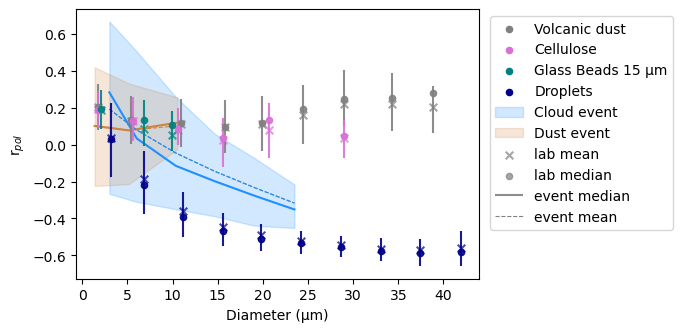

In [ ]:
names = ['Volcanic dust', 'Cellulose', 'Glass Beads 15 µm', #'Dust Svalbard',  'Dust Iceland', (entry 1 and 2 usually)
          'Droplets' ]
#df = [volcano, cellulose, glassbeads15, wick] #DustSvalbard, dustIceland, 
colours = ['grey',  'orchid', 'teal', 'darkblue'] #'olive', 'goldenrod',

n_sbo = [ 'Dust event', 'Cloud event']
'''df_sbo = [ dust, cloud]
c_sbo = [ 'peru', 'dodgerblue']'''
n_bins = 12
# plotmedian of the ratio of all experiments together (solids and droplets plotted separately)

fig, ax = plt.subplots( figsize=(7,3.5), )
    
for i in range(len(df)):
    mean, m, s, pm, ps = median_back_v_front(df[i], 'Diameter','scaled r_pol', n_bins)
    for j in range(len(m)-1):
        ax.scatter(m[j], pm[j], color = colours[i],  s = 20, alpha = 0.9,zorder = 4 ) # m = mean size, std = std size, pm = mean polarization, ps = std polarization #yerr = ps[j]),
        ax.scatter(m[j], mean[j], color = colours[i], s = 30, alpha = 0.7, marker = 'x', zorder = 2)
        ax.vlines(m[j], ymin = ps[j][0], ymax = ps[j][1], color = colours[i],alpha = 0.9, zorder = 3)
    ax.scatter(m[-1], pm[-1] , color = colours[i], label = names[i], s = 20) 
ax.vlines(m[-1], ymin = ps[-1][0], ymax = ps[-1][1], color = 'darkblue',alpha = 0.9, zorder = 2)
ax.scatter(m[-1], mean[-1], color = 'darkblue', s = 30, alpha = 0.7, marker = 'x',  zorder = 2)

ax.plot(cloud_params['ms'], cloud_params['pm'], c = 'dodgerblue')


ax.fill_between(cloud_params['ms'].astype(float), cloud_params['ps25'], cloud_params['ps75'], alpha = 0.2, color = 'dodgerblue', label = 'Cloud event')

ax.plot(dust_params['ms'], dust_params['pm'], c = 'peru')
ax.plot(dust_params['ms'], dust_params['mean'], c = 'peru',linestyle = '--', linewidth = 0.8)
ax.fill_between(dust_params['ms'].astype(float), dust_params['ps25'], dust_params['ps75'], alpha = 0.2, color = 'peru', label = 'Dust event')

ax.scatter(m[-1], mean[-1], color = 'grey', s = 30, alpha = 0.7, marker = 'x', label = 'lab mean', zorder = 0)
ax.scatter(m[-1], pm[-1], color = 'grey', s = 20, alpha = 0.7, label = 'lab median', zorder = 0)
ax.vlines(m[-1], ymin = ps[-1][0], ymax = ps[-1][1], color = 'grey',alpha = 0.9, label = 'event median', zorder = 1)
ax.plot(cloud_params['ms'], cloud_params['mean'], c = 'grey',linestyle = '--', label = 'event mean', linewidth = 0.8)
ax.plot(cloud_params['ms'], cloud_params['mean'], c = 'dodgerblue',linestyle = '--',  linewidth = 0.8)

fig.subplots_adjust(right=.7) 
ax.set(xlabel='Diameter (µm)', ylabel='r$_{pol}$',) #
ax.legend(bbox_to_anchor=(1.01, 1), fontsize = 10)
#fig.savefig('r_pol_labSBOtheory', dpi=300, bbox_inches='tight')
plt.show()

## Polarization fingerprint plots

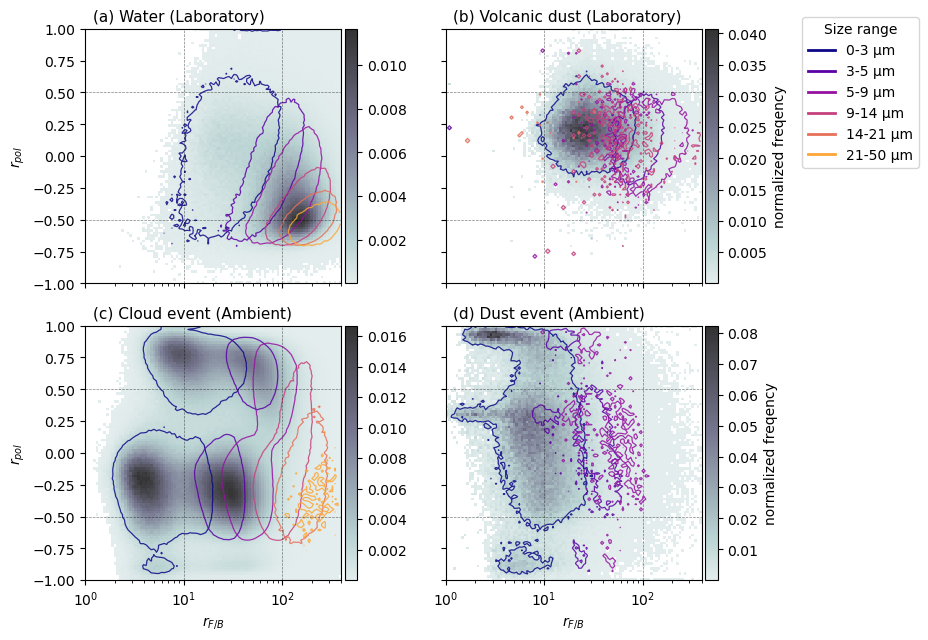

In [30]:
from matplotlib.lines import Line2D
bi = np.array([0,3,5,9,14,21,50])
ratio = np.logspace(np.log10(1), np.log10(400), 100)
bins = np.linspace(-1, 1, 100)

r = ['0-3', '3-5', '5-9', '9-14', '14-21', '21-50']
n = len(bi[1:])

# --------------------------------------------------
# color families per substance
# --------------------------------------------------

cmap = plt.cm.plasma #Greys_r #cubehelix_r #Blues # gist_earth #cividis #copper #
contour_colors = cmap(np.linspace(0, 0.8, n))   # light → dark
cmap = plt.cm.bone_r
hist2d_cmap = colors.LinearSegmentedColormap.from_list(
    "bone_r_crop",
    plt.cm.bone_r(np.linspace(0.1, 1, 256))
)

# --------------------------------------------------
# substance mapping to panels
# --------------------------------------------------
datasets = {
    "(a) Water (Laboratory)": wick,
    "(b) Volcanic dust (Laboratory)": volcano,
    "(c) Cloud event (Ambient)": cloud,
    "(d) Dust event (Ambient)": dust,   
}

# --------------------------------------------------
# figure
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(8,6.5), sharex=True, sharey=True)
axes = axes.ravel()

legend_handles = []

# --------------------------------------------------
# main plotting loop
# --------------------------------------------------
for ax, (name, df) in zip(axes, datasets.items()):
    
    #
    for i, k in enumerate(bi[1:]):
        color = contour_colors[i]
        subset = df[df['binned Diameter'] == k]

        if len(subset) <= 100:
            continue

        H, xedges, yedges = np.histogram2d(
            subset['scaled F/B'],
            subset['scaled r_pol'],
            bins=[ratio,bins],
            density = True,
        )

        if np.all(H == 0):
            continue

        xcenters = 0.5 * (xedges[1:] + xedges[:-1])
        ycenters = 0.5 * (yedges[1:] + yedges[:-1])
        X, Y = np.meshgrid(xcenters, ycenters)

        levels = np.linspace(H[H > 0].min(), H.max(), 9)[1:2] # single contour level at 1/8 of max
        if i >=5 and name == ('(b) Volcanic dust (Laboratory)' or "(d) Dust event (Ambient)"): # leave out the largest size bin for volcanic dust because it has very few data points and the contour is very noisy
            continue
            
        else:
            ax.contour(
                X, Y, H.T,
                levels=levels,
                colors=[color], 
                linewidths=0.9# + 0.2 * i
                , alpha = 0.85,
                
            )

        # legend proxies only once (first panel)
        if ax is axes[0]:
            legend_handles.append(
                Line2D([0], [0],
                       color=color,
                       lw=2,
                       label=f'{r[i]} µm')
            )
    h = ax.hist2d(
            df['scaled F/B'],
            df['scaled r_pol'],
            bins=[ratio,bins],
            cmap= hist2d_cmap, # 'bone_r', #'magma_r', # 'binary', #'pink', #
            cmin=1/len(df),
            alpha = 0.8,
            density = True,
        )
    ax.hlines(-0.5, xmin=1, xmax=1000, colors='k', linestyles='dashed', alpha=0.5, linewidth = 0.5)  
    ax.hlines(0.5, xmin=1, xmax=1000, colors='k', linestyles='dashed', alpha=0.5, linewidth = 0.5) 
    ax.vlines(10, ymin=-1, ymax=1, colors='k', linestyles='dashed', alpha=0.5, linewidth = 0.5)  
    ax.vlines(100, ymin=-1, ymax=1, colors='k', linestyles='dashed', alpha=0.5, linewidth = 0.5)  

    # label in colorbar only for ax[1] and ax[3] to avoid repetition
    if ax is axes[1] or ax is axes[3]:
        fig.colorbar(h[3] ,label ='normalized freqency', pad = 0.010 )
    else:
        fig.colorbar(h[3], pad = 0.010)  # add colorbar without ticks to save space
    ax.set( xscale = 'log')
    # add text instead of title
    ax.text(0.03, 1.03, name, transform=ax.transAxes, color='k', fontsize=11)

# shared y label
axes[3].set(xlabel = r'$r_{F/B}$')
axes[2].set(xlabel = r'$r_{F/B}$')
axes[0].set(ylabel = r'$r_{pol}$')
axes[2].set(ylabel = r'$r_{pol}$')

# --------------------------------------------------
# global legend (size encoding only)
# --------------------------------------------------
fig.legend(
    handles=legend_handles,
    title='Size range',
    bbox_to_anchor=(1, .85),
    loc='center left'
)

plt.tight_layout()
#fig.savefig('PvFB_hist2D', dpi=300, bbox_inches='tight')
plt.show()

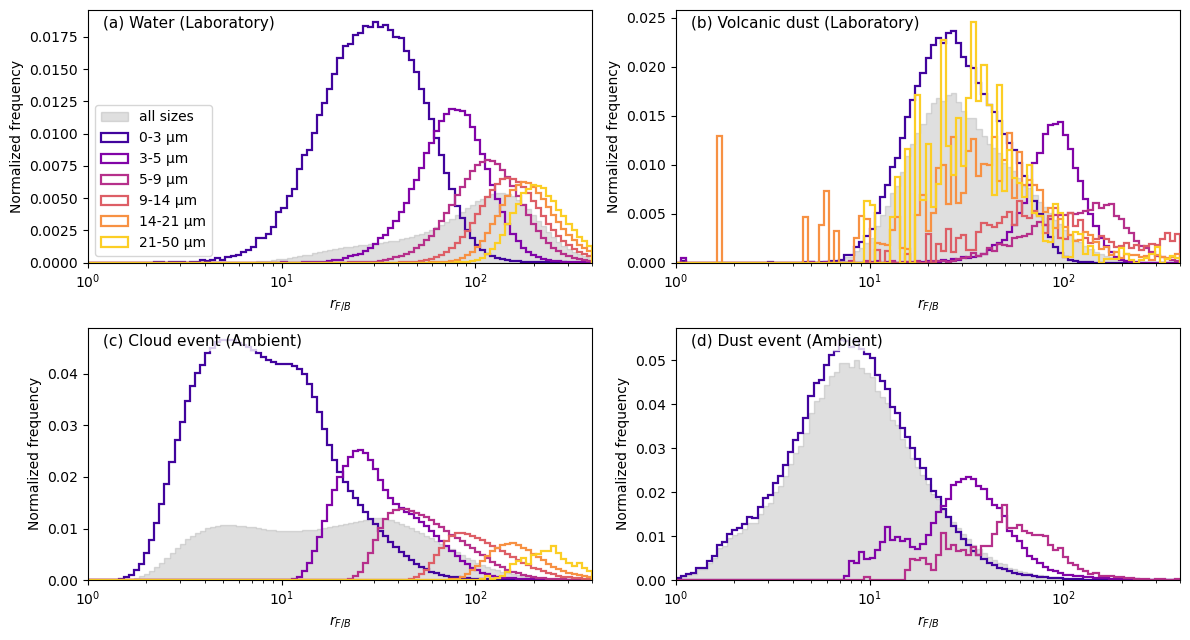

In [ ]:
datasets = {
    "(a) Water (Laboratory)": wick,
    "(b) Volcanic dust (Laboratory)": volcano,
    "(c) Cloud event (Ambient)": cloud,
    "(d) Dust event (Ambient)": dust,   
}

ratio = np.logspace(np.log10(1), np.log10(400), 100)
cmap = plt.cm.plasma
contour_colors = [cmap(v) for v in np.linspace(0.1, 0.9, n)]

fig, axes = plt.subplots(2, 2, figsize=(12,6.5))
axes = axes.ravel()

for ax, (name, df) in zip(axes, datasets.items()):

    # total distribution shadow
    counts, edges = np.histogram(df['scaled F/B'], bins=ratio, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])

    ax.fill_between(
        centers,
        counts,
        step="mid",
        color="grey",
        alpha=0.25,
        zorder=0,
        label ='all sizes' if ax is axes[0] else None
    )

    for i, k in enumerate(bi[1:]):
        color = contour_colors[i]
        subset = df[df['binned Diameter'] == k]

        if len(subset) <= 100:
            continue

        ax.hist(
            subset['scaled F/B'],
            bins=ratio,
            density=True,
            histtype='step',
            linewidth=1.6,
            color=color,
            label=f'{r[i]} µm' if ax is axes[0] else None
        )
    ax.set(
        xlabel=r'$r_{F/B}$',
        ylabel='Normalized frequency',
        xscale='log',
        xlim =(1, 400)
    )

    ax.text(
        0.03, .93, name,
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
    )

axes[0].legend()
plt.tight_layout()
#fig.savefig('SI_FB_hist', dpi = 300, bbox_inches ='tight')

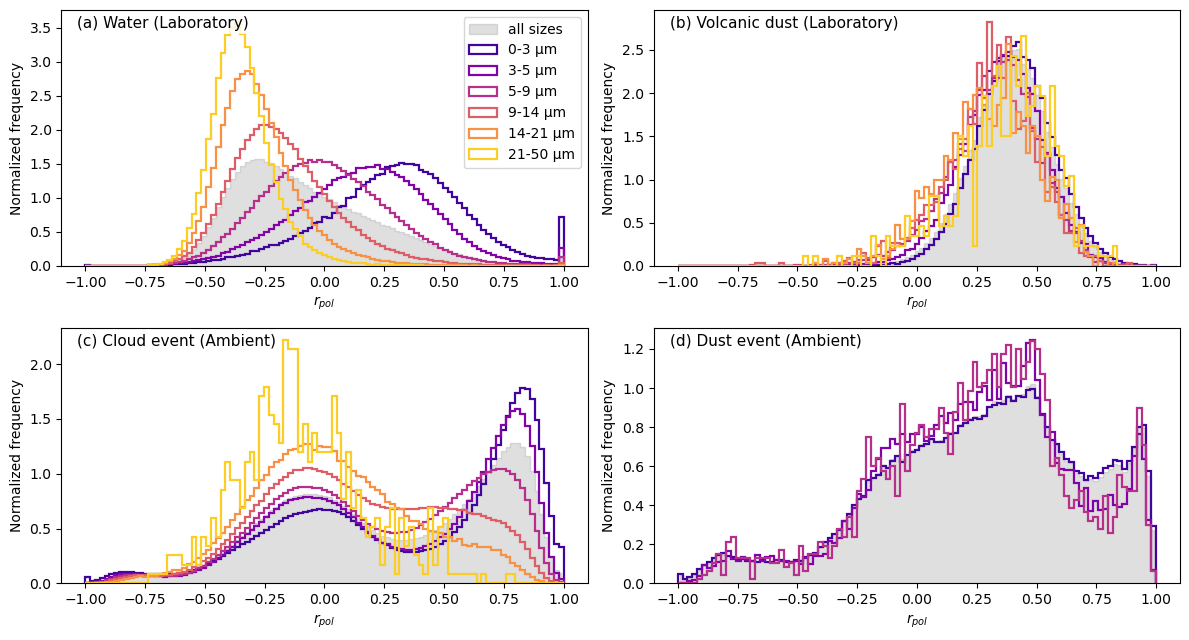

In [ ]:
ratio = np.linspace(-1,1, 100)
cmap = plt.cm.plasma
contour_colors = [cmap(v) for v in np.linspace(0.1, 0.9, n)]

fig, axes = plt.subplots(2, 2, figsize=(12,6.5))
axes = axes.ravel()

for ax, (name, df) in zip(axes, datasets.items()):

    # total distribution shadow
    counts, edges = np.histogram(df['scaled r_pol'], bins=ratio, density=True)
    centers = 0.5 * (edges[1:] + edges[:-1])

    ax.fill_between(
        centers,
        counts,
        step="mid",
        color="grey",
        alpha=0.25,
        zorder=0,
        label ='all sizes' if ax is axes[0] else None
    )

    for i, k in enumerate(bi[1:]):
        color = contour_colors[i]
        subset = df[df['binned Diameter'] == k]

        if len(subset) <= 100:
            continue

        ax.hist(
            subset['scaled r_pol'],
            bins=ratio,
            density=True,
            histtype='step',
            linewidth=1.6,
            color=color,
            label=f'{r[i]} µm' if ax is axes[0] else None
        )
    ax.set(
        xlabel=r'$r_{pol}$',
        ylabel='Normalized frequency',
        
    )

    ax.text(
        0.03, .93, name,
        transform=ax.transAxes,
        fontsize=11,
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none')
    )

axes[0].legend()
plt.tight_layout()
#fig.savefig('SI_rpol_hist', dpi = 300, bbox_inches ='tight')